# Luminosidad Estelar: Regresión Polinomial
## Parte II: Modelado de L con Características de Masa y Temperatura

**Objetivo**: Capturar efectos no lineales e interacciones usando ingeniería de características polinomiales.


$$X = [M, T, M^2, M \cdot T]$$

Modelo con sesgo explícito:

$$\hat{L} = X \mathbf{w} + b$$

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

print("Conjunto de datos:")
print(f"M (masas): {M}")
print(f"T (temperaturas): {T}")
print(f"L (luminosidades): {L}")
print(f"Número de muestras: {len(M)}")

Conjunto de datos:
M (masas): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
T (temperaturas): [3800 4400 5800 6400 6900 7400 7900 8300 8800 9200]
L (luminosidades): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]
Número de muestras: 10


## 1. Visualización del Conjunto de Datos

Graficar L vs M, codificando T con color o tamaño.

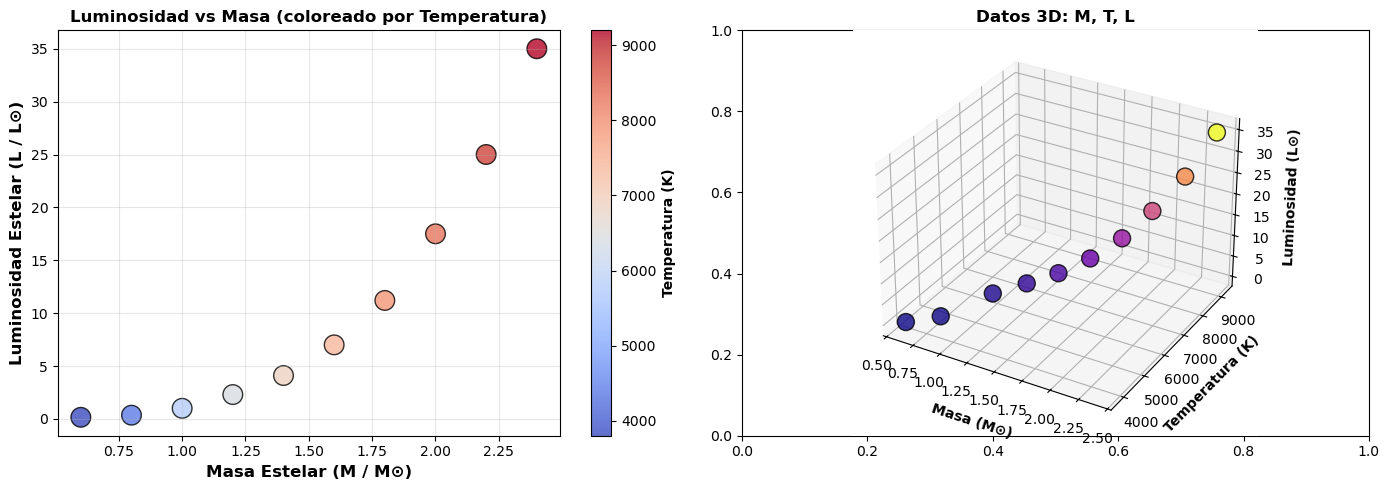


Observación:
La temperatura aumenta con la masa (correlación natural en secuencia principal).
La luminosidad muestra fuerte dependencia no lineal de M y T.


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
scatter1 = ax1.scatter(M, L, c=T, s=200, cmap='coolwarm', edgecolors='black', alpha=0.8)
ax1.set_xlabel('Masa Estelar (M / M⊙)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Luminosidad Estelar (L / L⊙)', fontsize=12, fontweight='bold')
ax1.set_title('Luminosidad vs Masa (coloreado por Temperatura)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Temperatura (K)', fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(M, T, L, s=150, c=L, cmap='plasma', edgecolors='black', alpha=0.8)
ax2.set_xlabel('Masa (M⊙)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Temperatura (K)', fontsize=10, fontweight='bold')
ax2.set_zlabel('Luminosidad (L⊙)', fontsize=10, fontweight='bold')
ax2.set_title('Datos 3D: M, T, L', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservación:")
print("La temperatura aumenta con la masa (correlación natural en secuencia principal).")
print("La luminosidad muestra fuerte dependencia no lineal de M y T.")

## 2. Ingeniería de Características

Construir la matriz de diseño X con características polinomiales y de interacción (sin columna de sesgo).

In [52]:
def build_design_matrix(M, T, include_M=True, include_T=True, include_M2=False, include_MT=False):
    features = []
    feature_names = []
    
    if include_M:
        features.append(M)
        feature_names.append('M')
    if include_T:
        features.append(T)
        feature_names.append('T')
    if include_M2:
        features.append(M**2)
        feature_names.append('M²')
    if include_MT:
        features.append(M * T)
        feature_names.append('M·T')
    
    X = np.column_stack(features)
    return X, feature_names

X_full, feature_names = build_design_matrix(
    M, T,
    include_M=True,
    include_T=True,
    include_M2=True,
    include_MT=True
)

print("Forma de X:", X_full.shape)
print("Características:", feature_names)
print("Primeras filas:\n", X_full[:3])

Forma de X: (10, 4)
Características: ['M', 'T', 'M²', 'M·T']
Primeras filas:
 [[6.00e-01 3.80e+03 3.60e-01 2.28e+03]
 [8.00e-01 4.40e+03 6.40e-01 3.52e+03]
 [1.00e+00 5.80e+03 1.00e+00 5.80e+03]]


## 3. Función de Pérdida y Gradientes (Vectorizados)

Definir MSE y calcular gradientes con respecto a w y b.

In [53]:
def predict_poly(X, w, b):
    """
    Calcula predicciones: L_hat = X @ w + b
    X: (n, p), w: (p,), b: escalar
    """
    return X @ w + b

def compute_mse_poly(X, L, w, b):
    """Calcula MSE para regresión polinomial"""
    n = X.shape[0]
    L_hat = predict_poly(X, w, b)
    mse = np.mean((L_hat - L) ** 2)
    return mse

def compute_gradients_poly(X, L, w, b):
    """
    Calcula gradientes vectorizados:
    dJ/dw = (2/n) * X.T @ (X @ w + b - L)
    dJ/db = (2/n) * sum(X @ w + b - L)
    """
    n = X.shape[0]
    L_hat = predict_poly(X, w, b)
    errors = L_hat - L
    
    dJ_dw = (2 / n) * X.T @ errors
    dJ_db = (2 / n) * np.sum(errors)
    
    return dJ_dw, dJ_db

w_init = np.zeros(X_full.shape[1])
b_init = 0.0
loss_init = compute_mse_poly(X_full, L, w_init, b_init)
dJ_dw_init, dJ_db_init = compute_gradients_poly(X_full, L, w_init, b_init)

print(f"Pérdida Inicial: {loss_init:.6f}")
print(f"Gradiente inicial dJ/dw: {dJ_dw_init}")
print(f"Gradiente inicial dJ/db: {dJ_db_init:.6f}")

Pérdida Inicial: 235.393500
Gradiente inicial dJ/dw: [-4.304600e+01 -1.756900e+05 -9.188680e+01 -3.708176e+05]
Gradiente inicial dJ/db: -20.720000


## 4a. Entrenamiento con Gradient Descent

In [54]:
def gradient_descent_poly(X, L, learning_rate, num_iterations, w_init=None, b_init=0.0, verbose=False):
    n, p = X.shape
    if w_init is None:
        w = np.zeros(p)
    else:
        w = w_init.copy()
    b = b_init
    loss_history = []

    for i in range(num_iterations):
        L_hat = X @ w + b
        errors = L_hat - L
        dJ_dw = (2 / n) * (X.T @ errors)
        dJ_db = (2 / n) * np.sum(errors)
        w -= learning_rate * dJ_dw
        b -= learning_rate * dJ_db
        loss = np.mean(errors ** 2)
        loss_history.append(loss)
        if verbose and (i + 1) % 200 == 0:
            print(f"Iteración {i+1}: Pérdida = {loss:.8f}")

    return w, b, np.array(loss_history)


X_full_scaled = normalize_features(X_full)

w_full, b_full, loss_full = gradient_descent_poly(
    X_full_scaled, L,
    learning_rate=0.01,
    num_iterations=2000,
    verbose=True
)

print(f"Pérdida Final: {loss_full[-1]:.8f}")
print(f"Parámetros finales w: {w_full}")
print(f"Intercepto final b: {b_full:.6f}")


Iteración 200: Pérdida = 11.61478120
Iteración 400: Pérdida = 7.91828479
Iteración 600: Pérdida = 5.66014041
Iteración 800: Pérdida = 4.26516072
Iteración 1000: Pérdida = 3.40093520
Iteración 1200: Pérdida = 2.86309893
Iteración 1400: Pérdida = 2.52600461
Iteración 1600: Pérdida = 2.31240170
Iteración 1800: Pérdida = 2.17479463
Iteración 2000: Pérdida = 2.08398165
Pérdida Final: 2.08398165
Parámetros finales w: [ 0.31818177 -7.82535869 12.01108355  6.00861796]
Intercepto final b: 10.360000


## 4b. Gráfico de Convergencia

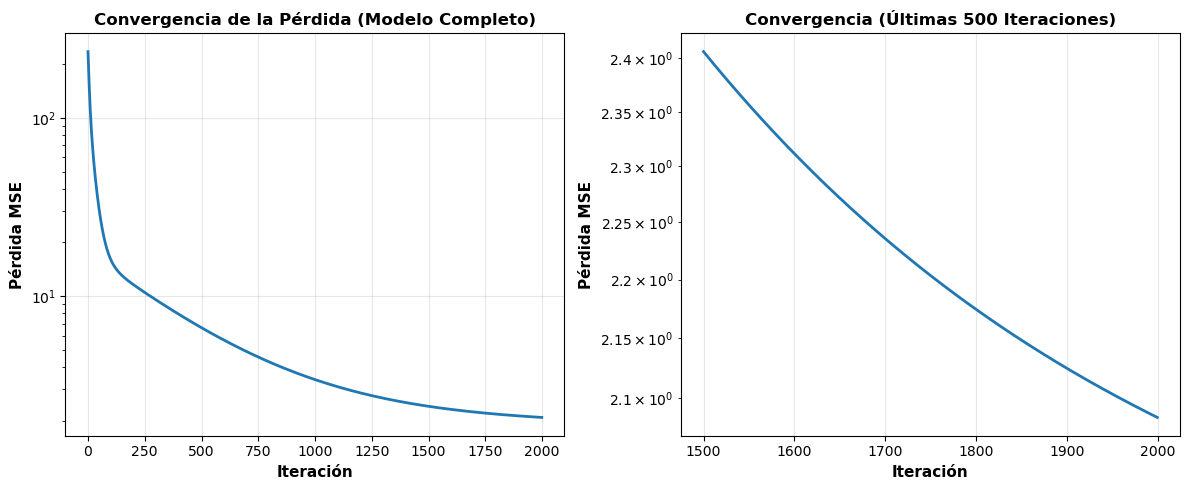

In [55]:
plt.figure(figsize=(12, 5))

# convergencia completa
plt.subplot(1, 2, 1)
plt.plot(loss_full, linewidth=2)
plt.xlabel('Iteración', fontsize=11, fontweight='bold')
plt.ylabel('Pérdida MSE', fontsize=11, fontweight='bold')
plt.title('Convergencia de la Pérdida (Modelo Completo)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Últimas iteraciones
plt.subplot(1, 2, 2)
iters = np.arange(len(loss_full) - 500, len(loss_full))
plt.plot(iters, loss_full[-500:], linewidth=2)
plt.xlabel('Iteración', fontsize=11, fontweight='bold')
plt.ylabel('Pérdida MSE', fontsize=11, fontweight='bold')
plt.title('Convergencia (Últimas 500 Iteraciones)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()


## 5a. Experimento de Selección de Características

Comparar tres modelos: M1 (M,T), M2 (M,T,M²), M3 (M,T,M²,M·T)

In [56]:
print("\n" + "="*70)
print("Modelo 1: X = [M, T]")
print("="*70)

X_m1, names_m1 = build_design_matrix(M, T, include_M=True, include_T=True)
X_m1 = normalize_features(X_m1)

w_m1, b_m1, loss_m1 = gradient_descent_poly(
    X_m1, L,
    learning_rate=0.01,
    num_iterations=2000
)

print(f"Pérdida Final: {loss_m1[-1]:.8f}")
print(f"Parámetros w: {w_m1}")
print(f"Intercepto b: {b_m1:.6f}")
print(f"Características: {names_m1}")

print("\n" + "="*70)
print("Modelo 2: X = [M, T, M²]")
print("="*70)

X_m2, names_m2 = build_design_matrix(M, T, include_M=True, include_T=True, include_M2=True)
X_m2 = normalize_features(X_m2)

w_m2, b_m2, loss_m2 = gradient_descent_poly(
    X_m2, L,
    learning_rate=0.01,
    num_iterations=2000
)

print(f"Pérdida Final: {loss_m2[-1]:.8f}")
print(f"Parámetros w: {w_m2}")
print(f"Intercepto b: {b_m2:.6f}")
print(f"Características: {names_m2}")

print("\n" + "="*70)
print("Modelo 3: X = [M, T, M², M·T]")
print("="*70)

X_m3, names_m3 = build_design_matrix(M, T, include_M=True, include_T=True, include_M2=True, include_MT=True)
X_m3 = normalize_features(X_m3)

w_m3, b_m3, loss_m3 = gradient_descent_poly(
    X_m3, L,
    learning_rate=0.005,
    num_iterations=3000
)

print(f"Pérdida Final: {loss_m3[-1]:.8f}")
print(f"Parámetros w: {w_m3}")
print(f"Intercepto b: {b_m3:.6f}")
print(f"Características: {names_m3}")



Modelo 1: X = [M, T]
Pérdida Final: 12.35575676
Parámetros w: [16.96900851 -6.87832979]
Intercepto b: 10.360000
Características: ['M', 'T']

Modelo 2: X = [M, T, M²]
Pérdida Final: 2.17752102
Parámetros w: [ 2.34343121 -6.90007284 15.10234602]
Intercepto b: 10.360000
Características: ['M', 'T', 'M²']

Modelo 3: X = [M, T, M², M·T]
Pérdida Final: 2.40718729
Parámetros w: [ 0.75892672 -7.10078441 11.12915012  5.72873938]
Intercepto b: 10.360000
Características: ['M', 'T', 'M²', 'M·T']


## 5b. Comparación de Modelos: Predicciones vs Valores Reales

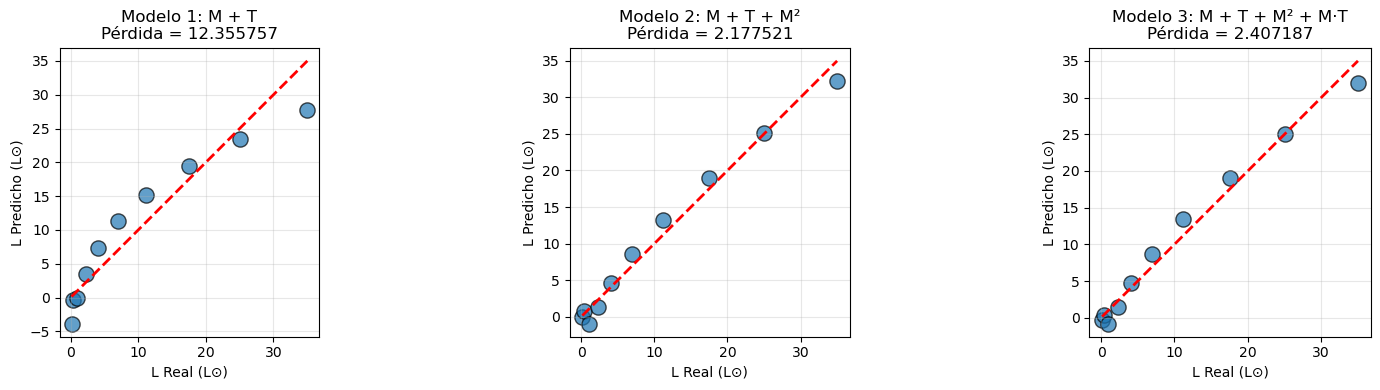


Resumen de Comparación de Modelos:
Pérdida M1: 12.35575676
Pérdida M2: 2.17752102
Pérdida M3: 2.40718729

Mejora M1→M2: 82.38%
Mejora M2→M3: -10.55%


In [57]:
def predict_poly(X, w, b):
    return X @ w + b


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

L_pred_m1 = predict_poly(X_m1, w_m1, b_m1)
ax1 = axes[0]
ax1.scatter(L, L_pred_m1, s=120, alpha=0.7, edgecolors='black')
ax1.plot([L.min(), L.max()], [L.min(), L.max()], 'r--', linewidth=2)
ax1.set_xlabel('L Real (L⊙)')
ax1.set_ylabel('L Predicho (L⊙)')
ax1.set_title(f'Modelo 1: M + T\nPérdida = {loss_m1[-1]:.6f}')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

L_pred_m2 = predict_poly(X_m2, w_m2, b_m2)
ax2 = axes[1]
ax2.scatter(L, L_pred_m2, s=120, alpha=0.7, edgecolors='black')
ax2.plot([L.min(), L.max()], [L.min(), L.max()], 'r--', linewidth=2)
ax2.set_xlabel('L Real (L⊙)')
ax2.set_ylabel('L Predicho (L⊙)')
ax2.set_title(f'Modelo 2: M + T + M²\nPérdida = {loss_m2[-1]:.6f}')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

L_pred_m3 = predict_poly(X_m3, w_m3, b_m3)
ax3 = axes[2]
ax3.scatter(L, L_pred_m3, s=120, alpha=0.7, edgecolors='black')
ax3.plot([L.min(), L.max()], [L.min(), L.max()], 'r--', linewidth=2)
ax3.set_xlabel('L Real (L⊙)')
ax3.set_ylabel('L Predicho (L⊙)')
ax3.set_title(f'Modelo 3: M + T + M² + M·T\nPérdida = {loss_m3[-1]:.6f}')
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("\nResumen de Comparación de Modelos:")
print(f"Pérdida M1: {loss_m1[-1]:.8f}")
print(f"Pérdida M2: {loss_m2[-1]:.8f}")
print(f"Pérdida M3: {loss_m3[-1]:.8f}")
print(f"\nMejora M1→M2: {(loss_m1[-1] - loss_m2[-1]) / loss_m1[-1] * 100:.2f}%")
print(f"Mejora M2→M3: {(loss_m2[-1] - loss_m3[-1]) / loss_m2[-1] * 100:.2f}%")


## 6. Costo vs Parámetro de Interacción

Para el modelo completo, variar el coeficiente de interacción w_MT manteniendo otros parámetros fijos.

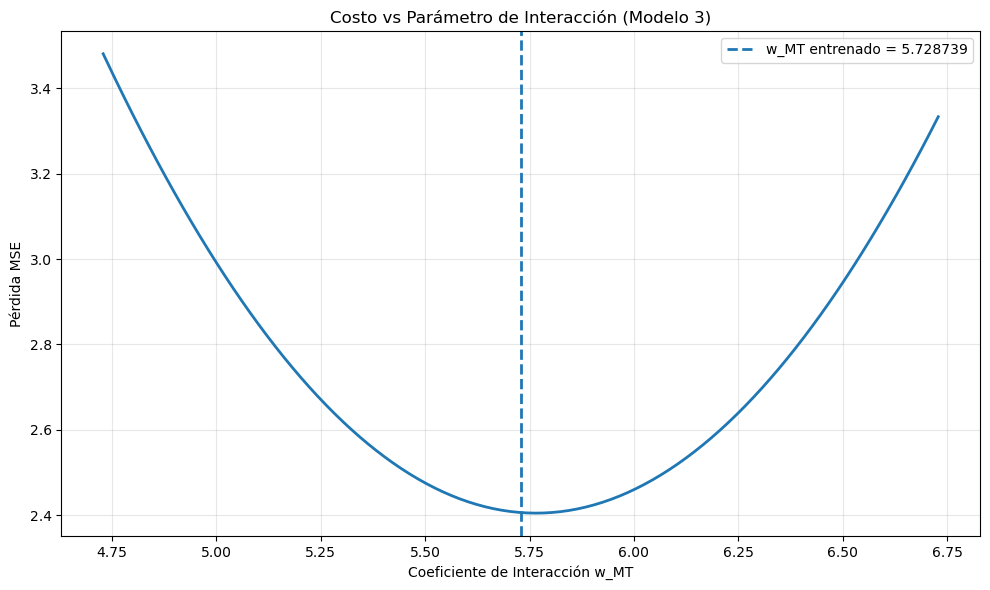

w_MT óptimo (barrido): 5.76391526
w_MT entrenado:        5.72873938
Costo mínimo:         2.40530496
Sensibilidad relativa: 44.69%


In [58]:
w_M_fixed = w_m3[0]
w_T_fixed = w_m3[1]
w_M2_fixed = w_m3[2]
b_fixed = b_m3

w_MT_range = np.linspace(w_m3[3] - 1.0, w_m3[3] + 1.0, 200)

cost_vs_MT = []

for w_MT_val in w_MT_range:
    w_temp = np.array([w_M_fixed, w_T_fixed, w_M2_fixed, w_MT_val])
    L_hat = X_m3 @ w_temp + b_fixed
    cost = np.mean((L_hat - L) ** 2)
    cost_vs_MT.append(cost)

cost_vs_MT = np.array(cost_vs_MT)

plt.figure(figsize=(10, 6))
plt.plot(w_MT_range, cost_vs_MT, linewidth=2)
plt.axvline(
    x=w_m3[3],
    linestyle='--',
    linewidth=2,
    label=f'w_MT entrenado = {w_m3[3]:.6f}'
)
plt.xlabel('Coeficiente de Interacción w_MT')
plt.ylabel('Pérdida MSE')
plt.title('Costo vs Parámetro de Interacción (Modelo 3)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

min_cost_idx = np.argmin(cost_vs_MT)
optimal_w_MT = w_MT_range[min_cost_idx]

print(f"w_MT óptimo (barrido): {optimal_w_MT:.8f}")
print(f"w_MT entrenado:        {w_m3[3]:.8f}")
print(f"Costo mínimo:         {cost_vs_MT[min_cost_idx]:.8f}")
print(f"Sensibilidad relativa: {(cost_vs_MT.max() - cost_vs_MT.min()) / cost_vs_MT.min() * 100:.2f}%")


## 7. Demo de Inferencia

Predecir luminosidad para una nueva estrella con M=1.3 M⊙, T=6600 K.

In [59]:
M_new = 1.3
T_new = 6600

X_new_m1 = np.array([[M_new, T_new]])
X_new_m2 = np.array([[M_new, T_new, M_new**2]])
X_new_m3 = np.array([[M_new, T_new, M_new**2, M_new*T_new]])

L_pred_new_m1 = predict_poly(X_new_m1, w_m1, b_m1)[0]
L_pred_new_m2 = predict_poly(X_new_m2, w_m2, b_m2)[0]
L_pred_new_m3 = predict_poly(X_new_m3, w_m3, b_m3)[0]

print("\n" + "="*70)
print(f"Demo de Inferencia: Prediciendo L para nueva estrella (M={M_new} M⊙, T={T_new} K)")
print("="*70)

print(f"\nModelo 1 (M + T): L̂ = {L_pred_new_m1:.6f} L⊙")
print(f"Modelo 2 (M + T + M²): L̂ = {L_pred_new_m2:.6f} L⊙")
print(f"Modelo 3 (M + T + M² + M·T): L̂ = {L_pred_new_m3:.6f} L⊙")

print(f"\nComparación con datos de entrenamiento:")
print(f"Rango L entrenamiento: [{L.min():.2f}, {L.max():.2f}] L⊙")
print(f"Rango M entrenamiento: [{M.min():.2f}, {M.max():.2f}] M⊙")
print(f"Rango T entrenamiento: [{T.min():.0f}, {T.max():.0f}] K")

print(f"\nUbicación nueva estrella:")
print(f"M={M_new} ({'dentro' if M.min() <= M_new <= M.max() else 'fuera'} del rango)")
print(f"T={T_new} ({'dentro' if T.min() <= T_new <= T.max() else 'fuera'} del rango)")

print(f"\nL predicho (Modelo 3): {L_pred_new_m3:.6f} L⊙")



Demo de Inferencia: Prediciendo L para nueva estrella (M=1.3 M⊙, T=6600 K)

Modelo 1 (M + T): L̂ = -45364.556932 L⊙
Modelo 2 (M + T + M²): L̂ = -45501.551296 L⊙
Modelo 3 (M + T + M² + M·T): L̂ = 2317.561599 L⊙

Comparación con datos de entrenamiento:
Rango L entrenamiento: [0.15, 35.00] L⊙
Rango M entrenamiento: [0.60, 2.40] M⊙
Rango T entrenamiento: [3800, 9200] K

Ubicación nueva estrella:
M=1.3 (dentro del rango)
T=6600 (dentro del rango)

L predicho (Modelo 3): 2317.561599 L⊙
